# Baseline models

All learned baselines use the same eligible training rows and train-only preprocessing. The final test remains locked. Persistence and Seasonal Persistence need no fitting and are added explicitly to every evaluation matrix. Quantile Forest uses weighted leaf training responses from the established quantile-forest implementation, not quantiles of tree means.

In [1]:
from pathlib import Path
import sys
_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'dataset').is_dir() and (p / 'notebooks').is_dir())
if str(_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(_root / 'notebooks'))
from _runtime import (reuse as _nb_reuse, source_document as _source_document,
                      initialize, repo_root as _repo_root, result_tables,
                      result_state, plot_data, figure_stem)
initialize()

from pathlib import Path
import json, hashlib, time, copy, os, threading
import numpy as np
import pandas as pd
import joblib, psutil
from IPython.display import display, Markdown
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from quantile_forest import RandomForestQuantileRegressor
from threadpoolctl import threadpool_limits
PROJECT_DIR=_repo_root()
TABLE_DIR,STATE_DIR,MODEL_DIR,PREDICT_DIR=[PROJECT_DIR/x for x in ['.cache/experiment/tables','.cache/experiment/state','.cache/experiment/models','.cache/experiment/predictions']]
for directory in [TABLE_DIR,STATE_DIR,MODEL_DIR,PREDICT_DIR]:directory.mkdir(exist_ok=True)
protocol=json.loads((STATE_DIR/'experiment_config.json').read_text())
assert json.loads((STATE_DIR/'temporal_consistency.json').read_text())['status']=='PASS'
modeling=pd.read_parquet(TABLE_DIR/'modeling_dataset.parquet')
feature_cols=json.loads((STATE_DIR/'main_preprocessing_state.json').read_text())['feature_columns']
pd.set_option('display.max_rows',100);pd.set_option('display.max_columns',20);pd.set_option('display.max_colwidth',None)
threadpool_limits(protocol['threads'])


## Shared preprocessing, metrics and measured runtime

In [2]:
def select_training_rows(frame,h,max_rows=36000):
    target=f'target_h{h}_net_load_kw'
    clean=frame.loc[frame[f'target_measured_h{h}']&frame[target].notna()].sort_values(['timestamp','site'])
    if len(clean)>max_rows:clean=clean.iloc[np.linspace(0,len(clean)-1,max_rows,dtype=int)]
    return clean

def fit_matrix(train,columns):
    cat=[c for c in columns if c in ['site','building_type','pv_regime']]
    num=[c for c in columns if c not in cat]
    median=train[num].median().fillna(0.)
    numeric=train[num].astype(float).replace([np.inf,-np.inf],np.nan).fillna(median)
    encoded=pd.get_dummies(train[cat].astype(str),dtype=float)
    matrix=pd.concat([numeric,encoded],axis=1)
    return {'columns':columns,'categorical':cat,'numeric':num,'median':median,'matrix_columns':matrix.columns.tolist()}

def transform_matrix(frame,state):
    numeric=frame[state['numeric']].astype(float).replace([np.inf,-np.inf],np.nan).fillna(state['median'])
    encoded=pd.get_dummies(frame[state['categorical']].astype(str),dtype=float)
    matrix=pd.concat([numeric,encoded],axis=1).reindex(columns=state['matrix_columns'],fill_value=0.)
    x=matrix.to_numpy(dtype=np.float32)
    assert np.isfinite(x).all()
    return x

runtime_rows=[]
def timed_fit(model,x,y,**kwargs):
    process=psutil.Process();baseline=process.memory_info().rss;peak=[baseline];stop=threading.Event()
    def sample_memory():
        while not stop.wait(.05):peak[0]=max(peak[0],process.memory_info().rss)
    monitor=threading.Thread(target=sample_memory,daemon=True);monitor.start();t=time.perf_counter()
    try:model.fit(x,y,**kwargs)
    finally:seconds=time.perf_counter()-t;stop.set();monitor.join()
    nodes=sum(t.tree_.node_count for t in getattr(model,'estimators_',[]) if hasattr(t,'tree_'))
    runtime_rows.append({'estimator':type(model).__name__,'fit_seconds':seconds,'n_train':len(y),'n_features':x.shape[1],'peak_rss_mb':peak[0]/1e6,'peak_rss_increase_mb':max(0,peak[0]-baseline)/1e6,'tree_node_count':nodes,'mode':'fresh_fit','threads':protocol['threads']})
    return model

def prediction_frame(frame,h,model,seed,origin,pred,lower=None,median=None,upper=None):
    out=frame[['timestamp','site','building_type','split','weak_signal_regime','high_interpolation_regime','pv_regime','endpoint_age_seconds']].copy()
    out['horizon_steps']=h;out['horizon_minutes']=h*15;out['model']=model;out['seed']=seed;out['origin']=origin
    out['target_timestamp']=frame[f'target_timestamp_h{h}'].values
    out['actual']=frame[f'target_h{h}_net_load_kw'].values
    out['actual_raw_unscreened']=frame[f'target_raw_unscreened_h{h}'].values
    out['target_measured']=frame[f'target_measured_h{h}'].values
    out['target_interpolated']=frame[f'target_interpolated_h{h}'].values
    out['target_endpoint_age_seconds']=frame[f'target_endpoint_age_h{h}'].values
    out['pred']=pred
    for name,value in [('lower',lower),('median',median),('upper',upper)]:out[name]=np.nan if value is None else value
    return out

def point_metrics(frame,reference='measured'):
    if reference=='measured':mask=frame.target_measured&frame.actual.notna();y=frame.loc[mask,'actual']
    elif reference=='supplier_interpolated':mask=frame.target_interpolated&frame.actual.notna();y=frame.loc[mask,'actual']
    elif reference=='raw_unscreened':mask=frame.actual_raw_unscreened.notna();y=frame.loc[mask,'actual_raw_unscreened']
    else:raise ValueError(reference)
    pred=frame.loc[mask,'pred']
    if len(y)==0:return {'n':0,'MAE':np.nan,'RMSE':np.nan,'R2':np.nan}
    return {'n':len(y),'MAE':float(mean_absolute_error(y,pred)),'RMSE':float(np.sqrt(mean_squared_error(y,pred))),'R2':float(r2_score(y,pred)) if len(y)>1 else np.nan}


def load_model(path):
    """Lossless sparse QRF loading without a dense Fortran-to-C reshape copy.

    quantile-forest 1.4.2 __setstate__ calls CSC.toarray().reshape(C-order).
    Requesting the same values directly in C order avoids the extra dense copy.
    The SciPy method is restored immediately; prediction algorithms are unchanged.
    """
    from scipy.sparse import csc_matrix
    original=csc_matrix.toarray;own=csc_matrix.__dict__.get('toarray')
    def toarray_c(self,order=None,out=None):
        return original(self,order='C' if order is None else order,out=out)
    csc_matrix.toarray=toarray_c
    try:return joblib.load(path)
    finally:
        if own is None:delattr(csc_matrix,'toarray')
        else:csc_matrix.toarray=own


## Conformal utilities (dedicated calibration only)

In [3]:
def conformity_score(y,lower,upper):
    y,lower,upper=[np.asarray(x,dtype=float) for x in (y,lower,upper)]
    if not(np.isfinite(y).all() and np.isfinite(lower).all() and np.isfinite(upper).all()):raise ValueError('Finite inputs required')
    if np.any(lower>upper):raise ValueError('Crossed interval')
    return np.maximum.reduce([lower-y,y-upper,np.zeros_like(y)])

def finite_sample_correction(scores,alpha=.10):
    scores=np.asarray(scores,dtype=float)
    if not 0<alpha<1 or len(scores)==0 or not np.isfinite(scores).all():raise ValueError('Invalid conformal calibration sample')
    k=int(np.ceil((len(scores)+1)*(1-alpha)))
    return float(np.partition(scores,k-1)[k-1]) if k<=len(scores) else float('inf')


## Baseline definitions and validation selection
The training cap and candidate grids are explicit. HGB uses a fixed random state and no random internal early-stopping split. ExtraTrees, RandomForest and QuantileForest are repeated across five seeds. Conformalized ExtraTrees reuses the fitted ExtraTrees point model and changes only intervals.

In [4]:
def memory_efficient_leaf_mapping(self,X,y,sorter=None,sample_weight=None):
    """Exact official bootstrap/leaf mapping; sparse writes avoid copying zero padding.

    Only the max_samples_leaf=None configuration used here is supported.
    All original response indices, multiplicities and ordering are retained.
    """
    from quantile_forest import _quantile_forest as implementation
    assert self.max_samples_leaf is None and y.shape[-1]==1
    n_samples=X.shape[0];n_outputs=y.shape[-1]
    leaves=self.apply(X)
    if self.bootstrap:
        args=(n_samples,self.max_samples)
        if implementation.sklearn_version>=implementation.parse_version('1.9.0'):args+=(self.sample_weight_,)
        n_bootstrap=implementation._get_n_samples_bootstrap(*args)
    else:n_bootstrap=n_samples
    bootstrap=np.empty((n_bootstrap,self.n_estimators),dtype=np.int64)
    bootstrap_leaves=np.empty_like(bootstrap)
    for i,estimator in enumerate(self.estimators_):
        if self.bootstrap:
            args=(estimator.random_state,n_samples,n_bootstrap)
            if implementation.sklearn_version>=implementation.parse_version('1.9.0'):args+=(self.sample_weight_,)
            bootstrap[:,i]=implementation._generate_sample_indices(*args)
        else:bootstrap[:,i]=np.arange(n_samples)
        bootstrap_leaves[:,i]=leaves[bootstrap[:,i],i]
    if sorter is not None:bootstrap=np.argsort(sorter,axis=0)[bootstrap]
    bootstrap=bootstrap.reshape(-1,self.n_estimators,n_outputs)+1
    max_nodes=max(estimator.tree_.node_count for estimator in self.estimators_)
    max_samples=max(int(np.bincount(bootstrap_leaves[:,i]).max()) for i in range(self.n_estimators))
    result=np.zeros((self.n_estimators,max_nodes,n_outputs,max_samples),dtype=np.int64)
    for i,estimator in enumerate(self.estimators_):
        values=self._get_y_train_leaves_slice(bootstrap[:,i],bootstrap_leaves[:,i],sample_weight,False,max_nodes,max_samples,estimator.random_state)
        nonzero=np.nonzero(values)
        result[i][nonzero]=values[nonzero]
    return result

def fit_memory_safe_quantile_forest(model,x,y):
    from types import MethodType
    model._get_y_train_leaves=MethodType(memory_efficient_leaf_mapping,model)
    try:return timed_fit(model,x,y,sparse_pickle=True)
    finally:del model._get_y_train_leaves


BASELINE_CONFIG={
 'Ridge':[{'alpha':.5},{'alpha':5.},{'alpha':25.}],
 'ExtraTrees':[{'n_estimators':90,'max_depth':14,'min_samples_leaf':4},{'n_estimators':110,'max_depth':18,'min_samples_leaf':6}],
 'RandomForest':[{'n_estimators':80,'max_depth':12,'min_samples_leaf':4},{'n_estimators':100,'max_depth':16,'min_samples_leaf':6}],
 'HGB':[{'max_iter':160,'learning_rate':.06,'max_leaf_nodes':31,'l2_regularization':.05},{'max_iter':220,'learning_rate':.04,'max_leaf_nodes':45,'l2_regularization':.10}],
 'QuantileForest':[{'n_estimators':90,'max_depth':14,'min_samples_leaf':4},{'n_estimators':110,'max_depth':18,'min_samples_leaf':6}],
 'QuantileHGB':[{'max_iter':180,'learning_rate':.05,'max_leaf_nodes':31,'l2_regularization':.05},{'max_iter':220,'learning_rate':.04,'max_leaf_nodes':45,'l2_regularization':.10}]
}

def fit_baseline(train,validation,h,name,seed,columns):
    assert train.split.eq('train').all() and validation.split.eq('validation').all()
    runtime_start=len(runtime_rows)
    target=f'target_h{h}_net_load_kw';fit=select_training_rows(train,h);val=validation.loc[validation[f'target_measured_h{h}']]
    state=fit_matrix(train,columns);x=transform_matrix(fit,state);xv=transform_matrix(val,state)
    y=fit[target].to_numpy();yv=val[target].to_numpy();candidates=[];models=[]
    for params in BASELINE_CONFIG[name]:
        if name=='Ridge':model=make_pipeline(StandardScaler(),Ridge(**params))
        elif name=='ExtraTrees':model=ExtraTreesRegressor(**params,random_state=seed,n_jobs=protocol['threads'])
        elif name=='RandomForest':model=RandomForestRegressor(**params,random_state=seed,n_jobs=protocol['threads'])
        elif name=='QuantileForest':model=RandomForestQuantileRegressor(**params,max_samples_leaf=None,random_state=seed,n_jobs=protocol['threads'])
        else:model=HistGradientBoostingRegressor(**params,random_state=0,early_stopping=False,**({'loss':'quantile','quantile':.5} if name=='QuantileHGB' else {}))
        fit_memory_safe_quantile_forest(model,x,y) if name=='QuantileForest' else timed_fit(model,x,y)
        pred=model.predict(xv,quantiles=.5,weighted_leaves=True) if name=='QuantileForest' else model.predict(xv)
        candidates.append({'params':params,'validation_MAE':float(mean_absolute_error(yv,pred))});models.append(model)
    best=int(np.argmin([r['validation_MAE'] for r in candidates]))
    bundle={'name':name,'seed':seed,'h':h,'matrix':state,'model':models[best],'selected':candidates[best],'candidates':candidates,'qhat':None}
    if name=='QuantileHGB':
        bundle['quantiles']={.5:models[best]}
        for q in [.05,.95]:bundle['quantiles'][q]=timed_fit(HistGradientBoostingRegressor(**candidates[best]['params'],loss='quantile',quantile=q,random_state=0,early_stopping=False),x,y)
    bundle['training_row_hash']=hashlib.sha256(pd.util.hash_pandas_object(fit[['site','timestamp']],index=False).values.tobytes()).hexdigest()
    for row in runtime_rows[runtime_start:]:row.update({'model':name,'horizon_minutes':15*h,'seed':seed})
    bundle['effective_parameters']=bundle['model'].get_params()
    if name=='QuantileForest':
        check=bundle['model'].predict(xv,quantiles=.5,weighted_leaves=True)
        assert abs(mean_absolute_error(yv,check)-bundle['selected']['validation_MAE'])<1e-10
    bundle['prediction_options']={'quantiles':[.05,.5,.95],'weighted_leaves':True,'weighted_quantile':True,'aggregate_leaves_first':True} if name=='QuantileForest' else {}
    return bundle

def predict_baseline(bundle,frame,calibrated=True):
    x=transform_matrix(frame,bundle['matrix']);model=bundle['model'];name=bundle['name']
    if name=='QuantileForest':q=np.sort(model.predict(x,quantiles=[.05,.5,.95],weighted_leaves=True),axis=1);point=q[:,1]
    elif name=='QuantileHGB':q=np.sort(np.column_stack([bundle['quantiles'][z].predict(x) for z in [.05,.5,.95]]),axis=1);point=q[:,1]
    else:point=model.predict(x);q=None
    if calibrated and bundle.get('qhat') is not None:
        if q is None:q=np.column_stack([point,point,point])
        q[:,0]-=bundle['qhat'];q[:,2]+=bundle['qhat']
    return point,q

def calibrate_baseline(bundle,calibration):
    h=bundle['h'];cal=calibration.loc[calibration[f'target_measured_h{h}']]
    assert cal.split.eq('calibration').all()
    point,q=predict_baseline(bundle,cal,calibrated=False)
    if q is None:lower=upper=point
    else:lower,upper=q[:,0],q[:,2]
    bundle['qhat']=finite_sample_correction(conformity_score(cal[f'target_h{h}_net_load_kw'],lower,upper),protocol['alpha'])
    return bundle


## Fit and freeze baseline configurations
This cell performs new model fitting and records fresh fit times, peak sampled process RSS and selected parameters. It never reads test targets or performs conformal calibration.

In [5]:
# Exact equivalence against the unmodified official implementation on a nontrivial bootstrap sample.
rng=np.random.default_rng(924);ux=rng.normal(size=(240,5)).astype(np.float32);uy=ux[:,0]**2+ux[:,1]+rng.normal(size=240)*.2
native=RandomForestQuantileRegressor(n_estimators=9,max_depth=7,min_samples_leaf=3,max_samples_leaf=None,random_state=17,n_jobs=1).fit(ux,uy)
optimized=RandomForestQuantileRegressor(n_estimators=9,max_depth=7,min_samples_leaf=3,max_samples_leaf=None,random_state=17,n_jobs=1)
unit_runtime_start=len(runtime_rows);fit_memory_safe_quantile_forest(optimized,ux,uy);del runtime_rows[unit_runtime_start:]
np.testing.assert_array_equal(np.asarray(native.forest_.y_train_leaves),np.asarray(optimized.forest_.y_train_leaves))
np.testing.assert_array_equal(native.predict(ux,quantiles=[.05,.5,.95],weighted_leaves=True),optimized.predict(ux,quantiles=[.05,.5,.95],weighted_leaves=True))
for a,b in zip(native.estimators_,optimized.estimators_):
    np.testing.assert_array_equal(a.tree_.threshold,b.tree_.threshold)
    np.testing.assert_array_equal(a.tree_.value,b.tree_.value)
del native,optimized


In [6]:
# Resume is valid only for the same data, protocol, grids and executable fit definitions.
import inspect,ast
resume_files=['.cache/experiment/tables/modeling_dataset.parquet','.cache/experiment/tables/causal_base_panel.parquet','.cache/experiment/tables/rolling_origin_splits.csv','.cache/experiment/state/experiment_config.json']
resume_contract={'files':{f:hashlib.sha256((PROJECT_DIR/f).read_bytes()).hexdigest() for f in resume_files},'baseline_grid':BASELINE_CONFIG,'QRF_mapping_ast':ast.dump(ast.parse(inspect.getsource(memory_efficient_leaf_mapping)),include_attributes=False),'fit_baseline_ast':ast.dump(ast.parse(inspect.getsource(fit_baseline)),include_attributes=False)}
resume_path=STATE_DIR/'notebook_03_resume_contract.json'
if resume_path.exists():assert json.loads(resume_path.read_text())==resume_contract,'Input or fit code changed; archive affected checkpoints before a fresh run.'
else:resume_path.write_text(json.dumps(resume_contract,indent=2,default=str))
selection_rows=pd.read_csv(TABLE_DIR/'baseline_validation_selection.csv').to_dict('records') if (TABLE_DIR/'baseline_validation_selection.csv').exists() else []
runtime_rows=pd.read_csv(TABLE_DIR/'baseline_fresh_fit_runtime.csv').to_dict('records') if (TABLE_DIR/'baseline_fresh_fit_runtime.csv').exists() else []
completed={(r['model'],int(r['horizon_minutes']),int(r['seed'])) for r in selection_rows}
progress=display(Markdown('Baseline selection on validation only'),display_id=True)
for h in protocol['horizons']:
    train=modeling.loc[modeling.split.eq('train')];validation=modeling.loc[modeling.split.eq('validation')]
    for name in BASELINE_CONFIG:
        seeds=protocol['seeds'] if name in ['ExtraTrees','RandomForest','QuantileForest'] else [0]
        for seed in seeds:
            if (name,15*h,seed) in completed:continue
            progress.update(Markdown(f'Fitting **{name}**, horizon **{15*h} min**, seed **{seed}**; test locked'))
            bundle=fit_baseline(train,validation,h,name,seed,feature_cols)
            stem=f'baseline_{name}_h{h}_seed{seed}'
            joblib.dump(bundle,MODEL_DIR/(stem+'.joblib'),compress=3)
            if name=='QuantileForest':
                restored=load_model(MODEL_DIR/(stem+'.joblib'))
                sample=validation.loc[validation[f'target_measured_h{h}']].iloc[:128]
                original_pred=predict_baseline(bundle,sample,calibrated=False)[1]
                restored_pred=predict_baseline(restored,sample,calibrated=False)[1]
                np.testing.assert_array_equal(original_pred,restored_pred)
                del restored
            selected={'model':name,'horizon_minutes':15*h,'seed':seed,**bundle['selected'],'training_row_hash':bundle['training_row_hash'],'effective_parameters':bundle['effective_parameters'],'prediction_options':bundle['prediction_options']}
            (STATE_DIR/(stem+'_config.json')).write_text(json.dumps(selected,indent=2,default=str))
            selection_rows.append(selected)
            pd.DataFrame(selection_rows).to_csv(TABLE_DIR/'baseline_validation_selection.csv',index=False)
            pd.DataFrame(runtime_rows).to_csv(TABLE_DIR/'baseline_fresh_fit_runtime.csv',index=False)
            progress.update(Markdown(f'Completed **{name}**, **{15*h} min**, seed **{seed}**; validation MAE **{bundle["selected"]["validation_MAE"]:.4f} kW**'))
            del bundle
(STATE_DIR/'baseline_selection_complete.json').write_text(json.dumps({'status':'COMPLETE','models':len(selection_rows),'test_accessed':False},indent=2))
display(pd.DataFrame(selection_rows)[['model','horizon_minutes','seed','validation_MAE']])


,model,horizon_minutes,seed,validation_MAE
0,Ridge,15,0,1.329923
1,ExtraTrees,15,11,1.209863
2,ExtraTrees,15,23,1.211199
3,ExtraTrees,15,37,1.213861
4,ExtraTrees,15,53,1.214476
5,ExtraTrees,15,71,1.210866
6,RandomForest,15,11,1.220865
7,RandomForest,15,23,1.223666
8,RandomForest,15,37,1.220777
9,RandomForest,15,53,1.221291


## Modern baselines and established STGCN

Five explicitly labelled lite baselines and a complete two-block STGCN share windows, target dates, train-only normalisation, four tuning trials, early stopping and five seeds. All neural results are conditional on the recorded local MPS training budget; they do not establish universal superiority over neural forecasting. STGCN implements gated temporal convolutions, Chebyshev graph convolutions and two ST blocks based on the authors' architecture.

Reference: https://github.com/VeritasYin/STGCN_IJCAI-18

DLinear has no hidden-width parameter: its effective tuning varies learning rate and history length. PatchTST-lite is the explicitly documented joint-feature patch Transformer variant; it is not claimed to reproduce the full channel-independent reference architecture. Exact module representations and parameter counts are exported for every fit.

The saved six-model neural experiment used Apple MPS in float32. New runs select an available CUDA, MPS or CPU device and record it in each configuration. Final inference is additionally timed on CPU alongside the tree models. CPU tree fitting and MPS neural fitting are reported separately; training-time ratios across devices do not establish algorithmic efficiency.

In [1]:
from pathlib import Path
import json, hashlib, time, copy, os, threading
import numpy as np
import pandas as pd
import joblib, psutil
from IPython.display import display, Markdown
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from quantile_forest import RandomForestQuantileRegressor
from threadpoolctl import threadpool_limits
PROJECT_DIR=_repo_root()
TABLE_DIR,STATE_DIR,MODEL_DIR,PREDICT_DIR=[PROJECT_DIR/x for x in ['.cache/experiment/tables','.cache/experiment/state','.cache/experiment/models','.cache/experiment/predictions']]
for directory in [TABLE_DIR,STATE_DIR,MODEL_DIR,PREDICT_DIR]:directory.mkdir(exist_ok=True)
protocol=json.loads((STATE_DIR/'experiment_config.json').read_text())
assert json.loads((STATE_DIR/'temporal_consistency.json').read_text())['status']=='PASS'
modeling=pd.read_parquet(TABLE_DIR/'modeling_dataset.parquet')
feature_cols=json.loads((STATE_DIR/'main_preprocessing_state.json').read_text())['feature_columns']
pd.set_option('display.max_rows',100);pd.set_option('display.max_columns',20);pd.set_option('display.max_colwidth',None)
threadpool_limits(protocol['threads'])

import torch
from torch import nn
from torch.utils.data import Dataset,DataLoader
import random
TORCH_DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu');torch.set_num_threads(protocol['threads'])
MODERN_CONFIG={'candidates':[{'learning_rate':.001,'hidden':32,'history':32},{'learning_rate':.0003,'hidden':64,'history':32},{'learning_rate':.001,'hidden':32,'history':96},{'learning_rate':.0003,'hidden':64,'history':96}],'max_epochs':30,'patience':5,'batch_size':64,'max_train_origins':4000,'gradient_clip':1.,'weight_decay':.0001,'dropout':.1,'device':str(TORCH_DEVICE),'precision':'float32','final_inference_device':'cpu','selection_seed':protocol['seeds'][0],'seeds':protocol['seeds'],'validation_score':'pooled MAE in kW','common_history_eligibility':96,'STGCN':{'blocks':2,'temporal_kernel':3,'chebyshev_order':3}}
(STATE_DIR/'modern_tuning_protocol.json').write_text(json.dumps(MODERN_CONFIG,indent=2))


## Aligned windows and train-only normalisation

In [2]:
sequence_features=['net_load_kw','pv_power_kw','data_quality_score','input_missing_flag','graph_neighbor_net_load_kw','graph_neighbor_pv_power_kw','net_load_ramp_kw','hour_sin','hour_cos','dayofweek_sin','dayofweek_cos']
site_order=sorted(modeling.site.unique());time_order=pd.DatetimeIndex(sorted(modeling.timestamp.unique()))
site_frame={site:modeling.loc[modeling.site.eq(site)].set_index('timestamp').reindex(time_order) for site in site_order}
xraw=np.stack([site_frame[site][sequence_features].to_numpy(dtype=float) for site in site_order],axis=1)
split_at_time=site_frame[site_order[0]]['split'].to_numpy();train_time=split_at_time=='train'
x_median=np.nanmedian(xraw[train_time],axis=0);x_median=np.nan_to_num(x_median)
xfilled=np.where(np.isfinite(xraw),xraw,x_median[None,:,:])
x_mean=xfilled[train_time].mean(axis=0);x_std=xfilled[train_time].std(axis=0);x_std=np.where(x_std<1e-6,1.,x_std)
xdata=((xfilled-x_mean)/x_std).astype(np.float32)
ymean=np.array([site_frame[s].loc[site_frame[s].split.eq('train'),'net_load_kw'].mean() for s in site_order],dtype=np.float32)
ystd=np.array([site_frame[s].loc[site_frame[s].split.eq('train'),'net_load_kw'].std() for s in site_order],dtype=np.float32);ystd=np.maximum(ystd,1e-6)
assert np.isfinite(xdata).all() and np.isfinite(ymean).all() and np.isfinite(ystd).all()
state=json.loads((STATE_DIR/'main_preprocessing_state.json').read_text())
adjacency=pd.DataFrame(state['graph_weights']).reindex(index=site_order,columns=site_order).to_numpy(dtype=float)
adjacency=(adjacency+adjacency.T)/2
D=np.diag(1/np.sqrt(np.maximum(adjacency.sum(axis=1),1e-12)))
L=np.eye(len(site_order))-D@adjacency@D
lmax=max(float(np.linalg.eigvalsh(L).max()),1e-8)
scaled_laplacian=torch.tensor(2*L/lmax-np.eye(len(site_order)),dtype=torch.float32)
np.savez(MODEL_DIR/'modern_normalization.npz',x_mean=x_mean,x_std=x_std,x_median=x_median,y_mean=ymean,y_std=ystd,sites=np.array(site_order),features=np.array(sequence_features))

def horizon_arrays(h):
    y=np.stack([site_frame[s][f'target_h{h}_net_load_kw'].to_numpy(dtype=float) for s in site_order],axis=1)
    mask=np.stack([site_frame[s][f'target_measured_h{h}'].fillna(False).to_numpy(dtype=bool) for s in site_order],axis=1)
    yn=np.nan_to_num((y-ymean[None,:])/ystd[None,:]).astype(np.float32)
    eligible=np.arange(len(time_order))>=MODERN_CONFIG['common_history_eligibility']-1
    indices={split:np.flatnonzero((split_at_time==split)&eligible&mask.any(axis=1)) for split in ['train','validation','calibration','test']}
    if len(indices['train'])>MODERN_CONFIG['max_train_origins']:indices['train']=indices['train'][np.linspace(0,len(indices['train'])-1,MODERN_CONFIG['max_train_origins'],dtype=int)]
    return yn,mask,indices

class WindowDataset(Dataset):
    def __init__(self,indices,y,mask,history):self.indices=indices;self.y=y;self.mask=mask;self.history=history
    def __len__(self):return len(self.indices)
    def __getitem__(self,j):
        i=self.indices[j]
        return torch.from_numpy(xdata[i-self.history+1:i+1]),torch.from_numpy(self.y[i]),torch.from_numpy(self.mask[i]),i

display(pd.DataFrame([{'horizon_minutes':15*h,'split':split,'n_origins':len(ix),'n_measured_targets':int(mask[ix].sum())} for h in protocol['horizons'] for y,mask,idx in [horizon_arrays(h)] for split,ix in idx.items()]))


,horizon_minutes,split,n_origins,n_measured_targets
0,15,train,4000,30838
1,15,validation,3801,30803
2,15,calibration,3801,30976
3,15,test,3802,32527
4,60,train,4000,30824
5,60,validation,3798,30779
6,60,calibration,3798,30950
7,60,test,3799,32504


## Architecture definitions and tensor checks

In [3]:
class PerSiteModel(nn.Module):
    def reshape_input(self,x):
        B,T,N,F=x.shape
        return x.permute(0,2,1,3).reshape(B*N,T,F),B,N

class GRULite(PerSiteModel):
    def __init__(self,F,H,T,N):
        super().__init__();self.gru=nn.GRU(F,H,batch_first=True);self.head=nn.Linear(H,1)
    def forward(self,x):
        z,B,N=self.reshape_input(x);z,_=self.gru(z);return self.head(z[:,-1]).reshape(B,N)

class CausalConv(nn.Module):
    def __init__(self,inc,outc,dilation):
        super().__init__();self.pad=2*dilation;self.conv=nn.Conv1d(inc,outc,3,padding=self.pad,dilation=dilation)
    def forward(self,x):return self.conv(x)[:,:,:-self.pad]

class TCNLite(PerSiteModel):
    def __init__(self,F,H,T,N):
        super().__init__();layers=[]
        for j,dilation in enumerate([1,2,4,8]):layers.extend([CausalConv(F if j==0 else H,H,dilation),nn.ReLU(),nn.Dropout(.1)])
        self.net=nn.Sequential(*layers);self.head=nn.Linear(H,1)
    def forward(self,x):
        z,B,N=self.reshape_input(x);return self.head(self.net(z.transpose(1,2))[:,:,-1]).reshape(B,N)

class DLinearLite(PerSiteModel):
    def __init__(self,F,H,T,N):
        super().__init__();self.trend=nn.Linear(T,1);self.season=nn.Linear(T,1);self.combine=nn.Linear(F,1)
    def forward(self,x):
        z,B,N=self.reshape_input(x);z=z.transpose(1,2)
        trend=torch.nn.functional.avg_pool1d(torch.nn.functional.pad(z,(12,12),mode='replicate'),25,stride=1)
        z=self.trend(trend)+self.season(z-trend)
        return self.combine(z.squeeze(-1)).reshape(B,N)

class PatchTSTLite(PerSiteModel):
    def __init__(self,F,H,T,N):
        super().__init__();self.patch=8;self.stride=4
        count=(T-8)//4+1;self.proj=nn.Linear(F*8,H);self.pos=nn.Parameter(torch.zeros(1,count,H))
        self.encoder=nn.TransformerEncoder(nn.TransformerEncoderLayer(H,4,dim_feedforward=2*H,dropout=.1,batch_first=True),num_layers=2,enable_nested_tensor=False)
        self.head=nn.Linear(H,1)
    def forward(self,x):
        z,B,N=self.reshape_input(x);z=z.unfold(1,self.patch,self.stride).reshape(B*N,-1,z.shape[-1]*self.patch)
        z=self.encoder(self.proj(z)+self.pos);return self.head(z.mean(1)).reshape(B,N)

class GraphTemporalMLPLite(PerSiteModel):
    def __init__(self,F,H,T,N):
        super().__init__();self.net=nn.Sequential(nn.Linear(F*T,H),nn.ReLU(),nn.Dropout(.1),nn.Linear(H,H),nn.ReLU(),nn.Linear(H,1))
    def forward(self,x):
        z,B,N=self.reshape_input(x);return self.net(z.reshape(B*N,-1)).reshape(B,N)

# STGCN follows the two ST-convolution blocks: gated temporal, Chebyshev graph,
# gated temporal, normalization, then temporal output projection.
# Reference: https://github.com/VeritasYin/STGCN_IJCAI-18
class TemporalGLU(nn.Module):
    def __init__(self,inc,outc,kernel):
        super().__init__();self.conv=nn.Conv2d(inc,2*outc,(kernel,1));self.res=nn.Conv2d(inc,outc,1) if inc!=outc else nn.Identity()
    def forward(self,x):
        p,q=self.conv(x).chunk(2,dim=1);return (p+self.res(x)[:,:,-p.shape[2]:,:])*torch.sigmoid(q)

class ChebGraph(nn.Module):
    def __init__(self,inc,outc,laplacian):
        super().__init__();self.register_buffer('laplacian',laplacian);self.proj=nn.Conv2d(3*inc,outc,1);self.res=nn.Conv2d(inc,outc,1)
    def forward(self,x):
        p1=torch.einsum('nm,bctm->bctn',self.laplacian,x)
        p2=2*torch.einsum('nm,bctm->bctn',self.laplacian,p1)-x
        return torch.relu(self.proj(torch.cat([x,p1,p2],dim=1))+self.res(x))

class STBlock(nn.Module):
    def __init__(self,inc,H,N):
        super().__init__();G=max(16,H//4)
        self.temp1=TemporalGLU(inc,H,3);self.graph=ChebGraph(H,G,scaled_laplacian);self.temp2=TemporalGLU(G,H,3)
        self.norm=nn.LayerNorm([N,H]);self.drop=nn.Dropout(.1)
    def forward(self,x):
        z=self.temp2(self.graph(self.temp1(x)));return self.drop(self.norm(z.permute(0,2,3,1)).permute(0,3,1,2))

class STGCN(nn.Module):
    def __init__(self,F,H,T,N):
        super().__init__();self.blocks=nn.Sequential(STBlock(F,H,N),STBlock(H,H,N));self.output=nn.Sequential(TemporalGLU(H,H,T-8),nn.Conv2d(H,1,1))
    def forward(self,x):return self.output(self.blocks(x.permute(0,3,1,2))).squeeze(1).squeeze(1)

MODERN_MODELS={'GRU-lite':GRULite,'TCN-lite':TCNLite,'DLinear-lite':DLinearLite,'PatchTST-lite':PatchTSTLite,'GraphTemporalMLP-lite':GraphTemporalMLPLite,'STGCN':STGCN}
# Shape and finite-output checks use training inputs only.
probe=torch.from_numpy(xdata[100:132][None,:,:,:])
for name,cls in MODERN_MODELS.items():
    cpu_model=cls(len(sequence_features),32,32,len(site_order)).eval()
    with torch.no_grad():cpu_out=cpu_model(probe)
    model=cls(len(sequence_features),32,32,len(site_order)).to(TORCH_DEVICE);out=model(probe.to(TORCH_DEVICE))
    assert out.shape==(1,len(site_order)) and torch.isfinite(out).all(),name
    model.load_state_dict(cpu_model.state_dict());model.eval()
    with torch.no_grad():matched=model(probe.to(TORCH_DEVICE)).cpu()
    torch.testing.assert_close(cpu_out,matched,rtol=2e-4,atol=2e-5)

(torch.mps.synchronize() if TORCH_DEVICE.type=='mps' else torch.cuda.synchronize() if TORCH_DEVICE.type=='cuda' else None);del model,out;(torch.mps.empty_cache() if TORCH_DEVICE.type=='mps' else None)


## Visible training, validation and epoch progress

In [4]:
import ast,nbformat
training_document=_source_document('08')
class_sources={node.name:ast.dump(node,include_attributes=False) for cell in training_document.cells if cell.cell_type=='code' for node in ast.parse(cell.source).body if isinstance(node,ast.ClassDef)}
modern_contract={'dataset_sha256':hashlib.sha256((TABLE_DIR/'modeling_dataset.parquet').read_bytes()).hexdigest(),'preprocessing_sha256':hashlib.sha256((STATE_DIR/'main_preprocessing_state.json').read_bytes()).hexdigest(),'torch_version':torch.__version__,'config':MODERN_CONFIG,'architectures':{name:class_sources[cls.__name__] for name,cls in MODERN_MODELS.items()}}
modern_contract['training_code_sha256']=hashlib.sha256('\n'.join(training_document.cells[i].source for i in [1,3,5,7,9]).encode()).hexdigest()
modern_contract_path=STATE_DIR/'modern_resume_contract.json'
if modern_contract_path.exists():assert json.loads(modern_contract_path.read_text())==modern_contract,'Neural design or data changed; invalidate affected trial checkpoints.'
else:modern_contract_path.write_text(json.dumps(modern_contract,indent=2))
TRIAL_DIR=MODEL_DIR/'modern_trials';TRIAL_DIR.mkdir(exist_ok=True)
checkpoint_reuse=[]
curve_rows=pd.read_csv(TABLE_DIR/'modern_training_curves.csv').to_dict('records') if (TABLE_DIR/'modern_training_curves.csv').exists() else []
budget_rows=pd.read_csv(TABLE_DIR/'modern_computational_budget.csv').to_dict('records') if (TABLE_DIR/'modern_computational_budget.csv').exists() else []
def _fit_modern_impl(name,h,seed,config,progress,phase):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    y,mask,idx=horizon_arrays(h)
    train=WindowDataset(idx['train'],y,mask,config['history']);val=WindowDataset(idx['validation'],y,mask,config['history'])
    generator=torch.Generator().manual_seed(seed)
    train_loader=DataLoader(train,batch_size=MODERN_CONFIG['batch_size'],shuffle=True,generator=generator,num_workers=0)
    val_loader=DataLoader(val,batch_size=MODERN_CONFIG['batch_size'],shuffle=False,num_workers=0)
    model=MODERN_MODELS[name](len(sequence_features),config['hidden'],config['history'],len(site_order)).to(TORCH_DEVICE)
    optimizer=torch.optim.AdamW(model.parameters(),lr=config['learning_rate'],weight_decay=MODERN_CONFIG['weight_decay'])
    scale=torch.as_tensor(ystd,dtype=torch.float32,device=TORCH_DEVICE);(torch.mps.synchronize() if TORCH_DEVICE.type=='mps' else torch.cuda.synchronize() if TORCH_DEVICE.type=='cuda' else None);best=np.inf;best_state=None;best_epoch=0;stale=0;begin=time.perf_counter();peak=psutil.Process().memory_info().rss
    for epoch in range(1,MODERN_CONFIG['max_epochs']+1):
        model.train();total_loss=0.;total_n=0
        for x,yt,m,i in train_loader:
            x,yt,m=x.to(TORCH_DEVICE),yt.to(TORCH_DEVICE),m.to(TORCH_DEVICE)
            optimizer.zero_grad(set_to_none=True);pred=model(x);loss=((pred-yt).abs()*scale)[m].mean()
            assert torch.isfinite(loss)
            loss.backward();nn.utils.clip_grad_norm_(model.parameters(),MODERN_CONFIG['gradient_clip']);optimizer.step()
            total_loss+=float(loss.detach())*int(m.sum());total_n+=int(m.sum())
        model.eval();val_error=0.;val_n=0
        with torch.no_grad():
            for x,yt,m,i in val_loader:
                x,yt,m=x.to(TORCH_DEVICE),yt.to(TORCH_DEVICE),m.to(TORCH_DEVICE)
                val_error+=float((((model(x)-yt).abs()*scale)[m]).sum());val_n+=int(m.sum())
        score=val_error/val_n
        curve_rows.append({'model':name,'horizon_minutes':15*h,'seed':seed,'phase':phase,**config,'epoch':epoch,'train_MAE':total_loss/total_n,'validation_MAE':score})
        pd.DataFrame(curve_rows).to_csv(TABLE_DIR/'modern_training_curves.csv',index=False)
        peak=max(peak,psutil.Process().memory_info().rss)
        progress.update(Markdown(f'**{name}**, **{15*h} min**, seed **{seed}**, {phase}: epoch **{epoch}/30**, validation MAE **{score:.4f} kW**'))
        if score<best-1e-6:best=score;best_epoch=epoch;best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()};stale=0
        else:stale+=1
        if stale>=MODERN_CONFIG['patience']:break
    model.load_state_dict(best_state);(torch.mps.synchronize() if TORCH_DEVICE.type=='mps' else torch.cuda.synchronize() if TORCH_DEVICE.type=='cuda' else None)
    info={'model':name,'horizon_minutes':15*h,'seed':seed,'phase':phase,**config,'n_parameters':sum(p.numel() for p in model.parameters()),'epochs_run':epoch,'best_validation_epoch':best_epoch,'best_validation_MAE':best,'training_seconds':time.perf_counter()-begin,'peak_rss_mb':peak/1e6,'n_train_origins':len(train),'n_train_target_rows':int(mask[idx['train']].sum()),'n_validation_origins':len(val),'n_validation_target_rows':int(mask[idx['validation']].sum()),'max_epochs':MODERN_CONFIG['max_epochs'],'patience':MODERN_CONFIG['patience'],'threads':protocol['threads'],'device':str(TORCH_DEVICE),'precision':'float32'}
    info['architecture_repr']=str(model)
    info['hidden_parameter_used']=name!='DLinear-lite'
    info['implementation_scope']='Joint-feature patch Transformer inspired by PatchTST; compact variant' if name=='PatchTST-lite' else ('Two-block Chebyshev STGCN reimplementation' if name=='STGCN' else 'Documented compact architecture')
    budget_rows.append(info);pd.DataFrame(budget_rows).to_csv(TABLE_DIR/'modern_computational_budget.csv',index=False)
    return best_state,info


def fit_modern(name,h,seed,config,progress,phase):
    trial_key=hashlib.sha256(json.dumps({'model':name,'horizon':h,'seed':seed,'configuration':config,'phase':phase,'contract':modern_contract},sort_keys=True).encode()).hexdigest()
    trial_path=TRIAL_DIR/(trial_key+'.pt')
    if trial_path.exists():
        began=time.perf_counter();cached=torch.load(trial_path,map_location='cpu',weights_only=False)
        checkpoint_reuse.append({'model':name,'horizon_minutes':15*h,'seed':seed,'phase':phase,'mode':'reused_complete_trial','load_seconds':time.perf_counter()-began,'checkpoint':trial_key})
        pd.DataFrame(checkpoint_reuse).to_csv(TABLE_DIR/'modern_checkpoint_reuse.csv',index=False)
        return cached['state'],cached['info']
    process=psutil.Process();peak=[process.memory_info().rss];mps_peak=[(torch.mps.driver_allocated_memory() if TORCH_DEVICE.type=='mps' else 0)];stop=threading.Event()
    def sample():
        while not stop.wait(.05):
            peak[0]=max(peak[0],process.memory_info().rss);mps_peak[0]=max(mps_peak[0],(torch.mps.driver_allocated_memory() if TORCH_DEVICE.type=='mps' else 0))
    monitor=threading.Thread(target=sample,daemon=True);monitor.start()
    try:state,info=_fit_modern_impl(name,h,seed,config,progress,phase)
    finally:stop.set();monitor.join()
    info['peak_rss_mb']=max(info['peak_rss_mb'],peak[0]/1e6)
    info['memory_sampling_seconds']=.05
    info['peak_mps_driver_allocated_mb']=mps_peak[0]/1e6
    info['memory_note']='MPS allocation and RSS share unified RAM; do not add them'
    (torch.mps.empty_cache() if TORCH_DEVICE.type=='mps' else None)
    torch.save({'state':state,'info':info,'trial_key':trial_key},trial_path)
    pd.DataFrame(budget_rows).to_csv(TABLE_DIR/'modern_computational_budget.csv',index=False)
    return state,info


## Four-trial tuning and five-seed experiments

In [5]:
modern_selected=[];progress=display(Markdown('Modern baseline tuning: identical four-trial budget and validation dates'),display_id=True)
for h in protocol['horizons']:
    for name in MODERN_MODELS:
        candidates=[]
        for number,config in enumerate(MODERN_CONFIG['candidates'],1):
            state,info=fit_modern(name,h,MODERN_CONFIG['selection_seed'],config,progress,f'trial_{number}')
            candidates.append((info['best_validation_MAE'],state,info))
        _,best_state,best_info=min(candidates,key=lambda x:x[0]);best_config={k:best_info[k] for k in ['learning_rate','hidden','history']}
        for seed in protocol['seeds']:
            if seed==MODERN_CONFIG['selection_seed']:state,info=best_state,best_info
            else:state,info=fit_modern(name,h,seed,best_config,progress,'selected_seed_repeat')
            stem=f'modern_{name}_h{h}_seed{seed}'
            torch.save({'state_dict':state,'config':best_config,'name':name,'h':h,'seed':seed,'site_order':site_order,'sequence_features':sequence_features},MODEL_DIR/(stem+'.pt'))
            (STATE_DIR/(stem+'_config.json')).write_text(json.dumps(info,indent=2))
            modern_selected.append(info)
            pd.DataFrame(modern_selected).to_csv(TABLE_DIR/'modern_selected_validation_configs.csv',index=False)
(STATE_DIR/'modern_selection_complete.json').write_text(json.dumps({'status':'COMPLETE','models':len(modern_selected),'test_accessed':False},indent=2))
display(pd.DataFrame(modern_selected)[['model','horizon_minutes','seed','best_validation_MAE','n_parameters','epochs_run','best_validation_epoch','training_seconds']])


,model,horizon_minutes,seed,best_validation_MAE,n_parameters,epochs_run,best_validation_epoch,training_seconds
0,GRU-lite,15,11,1.203475,4353,30,30,224.942403
1,GRU-lite,15,23,1.212197,4353,23,18,183.388634
2,GRU-lite,15,37,1.220129,4353,17,12,131.619218
3,GRU-lite,15,53,1.200896,4353,26,21,196.501382
4,GRU-lite,15,71,1.210262,4353,28,23,213.833823
5,TCN-lite,15,11,1.250200,39297,30,26,78.693516
6,TCN-lite,15,23,1.265044,39297,19,14,47.149471
7,TCN-lite,15,37,1.253330,39297,21,16,56.721130
8,TCN-lite,15,53,1.255408,39297,25,20,66.782726
9,TCN-lite,15,71,1.239348,39297,28,23,72.414767


## Lag-Llama zero-shot experiment
The official checkpoint is evaluated in a project-local environment because its dependency constraints differ from the main environment. The full computation is visible below. Context length is selected on 512 fixed validation observations per horizon. Calibration (512) and final test (1024) observations are fixed before final evaluation. Other models are compared on exactly these rows in a separate matched-subset table; these estimates must not be mixed with full-test rankings. Five inference seeds provide 20 Monte Carlo samples each. No fine-tuning is performed.

Official source: https://github.com/time-series-foundation-models/lag-llama

In [6]:
FOUNDATION_SOURCE = r'''
from pathlib import Path
import numpy as np,pandas as pd,sklearn
import torch,json,copy,time,hashlib,sys,platform
from lag_llama.gluon.estimator import LagLlamaEstimator
from lag_llama.gluon.lightning_module import LagLlamaLightningModule
from gluonts.dataset.common import ListDataset
ROOT=Path.cwd()
REPORT=ROOT/'.cache/experiment/state';TABLE=ROOT/'.cache/experiment/tables';PRED=ROOT/'.cache/experiment/predictions';MODEL=ROOT/'.cache/experiment/models'
PHASE=sys.argv[1] if len(sys.argv)>1 else 'select'
torch.set_num_threads(4)
protocol=json.loads((REPORT/'experiment_config.json').read_text())
info=json.loads((REPORT/'lag_llama_checkpoint.json').read_text())
assert hashlib.sha256((ROOT/info['checkpoint']).read_bytes()).hexdigest()==info['sha256']
checkpoint=torch.load(ROOT/info['checkpoint'],map_location='cpu',weights_only=False)
panel=pd.read_parquet(TABLE/'modeling_dataset.parquet')
series={site:g.sort_values('timestamp').set_index('timestamp')['persistence'] for site,g in panel.groupby('site')}
FOUNDATION_CONFIG={'regime':'zero_shot; no fine_tuning','context_candidates':[32,96],'num_samples_per_seed':20,'seeds':protocol['seeds'],'validation_budget':512,'calibration_budget':512,'test_budget':1024,'checkpoint':info,'training_corpus_map':checkpoint['hyper_parameters'].get('data_id_to_name_map',{}),'pretraining_overlap':'OPSD is not named in the checkpoint dataset map; exact pretraining overlap has not been independently audited.','comparison':'Dedicated matched-row subset, separate from full-test rankings','dtype':'float32','device':'cpu','threads':4}

def subset(h,split,budget):
    frame=panel.loc[panel.split.eq(split)&panel[f'target_measured_h{h}']].sort_values(['timestamp','site'])
    if len(frame)>budget:frame=frame.iloc[np.linspace(0,len(frame)-1,budget,dtype=int)]
    return frame

def predictor_for(h,context):
    hp=copy.deepcopy(checkpoint['hyper_parameters']);hp['prediction_length']=h;hp['context_length']=context
    hp['model_kwargs']['context_length']=context;hp['model_kwargs']['num_parallel_samples']=20;hp['use_kv_cache']=False
    module=LagLlamaLightningModule(**hp);module.load_state_dict(checkpoint['state_dict'],strict=True);module.eval()
    k=hp['model_kwargs']
    est=LagLlamaEstimator(prediction_length=h,context_length=context,input_size=k['input_size'],n_layer=k['n_layer'],n_embd_per_head=k['n_embd_per_head'],n_head=k['n_head'],scaling=k['scaling'],time_feat=k['time_feat'],num_parallel_samples=20,batch_size=16,device=torch.device('cpu'))
    est.lags_seq=k['lags_seq']
    return est.create_predictor(est.create_transformation(),module),sum(p.numel() for p in module.parameters())

def forecast_rows(frame,h,context,seed):
    torch.manual_seed(seed);np.random.seed(seed);predictor,parameters=predictor_for(h,context)
    items=[]
    max_lag=max(checkpoint['hyper_parameters']['model_kwargs']['lags_seq'])
    for row in frame.itertuples():
        s=series[row.site];end=s.index.get_loc(row.timestamp);start=max(0,end+1-context-max_lag)
        values=s.iloc[start:end+1].to_numpy(dtype=np.float32)
        assert np.isfinite(values).all() and s.index[end]<=row.timestamp
        items.append({'start':pd.Period(s.index[start].tz_localize(None),freq='15min'),'target':values,'item_id':str(row.Index)})
    forecasts=predictor.predict(ListDataset(items,freq='15min'),num_samples=20)
    rows=[];begin=time.perf_counter()
    for j,(row,forecast) in enumerate(zip(frame.itertuples(),forecasts),1):
        assert pd.Timestamp(str(forecast.start_date)).tz_localize('UTC')==row.timestamp+pd.Timedelta(minutes=15)
        samples=forecast.samples[:,-1]
        assert np.isfinite(samples).all()
        q=np.quantile(samples,[.05,.5,.95])
        rows.append({'timestamp':row.timestamp,'target_timestamp':getattr(row,f'target_timestamp_h{h}'),'site':row.site,'building_type':row.building_type,'split':row.split,'horizon_steps':h,'horizon_minutes':15*h,'model':'Lag-Llama zero-shot','origin':0,'seed':seed,'actual':getattr(row,f'target_h{h}_net_load_kw'),'pred':q[1],'lower':q[0],'median':q[1],'upper':q[2],'target_measured':True,'target_interpolated':False,'benchmark_partition':'foundation_matched_subset'})
        if j%64==0:print(f'Lag-Llama {PHASE}: h={15*h}, context={context}, seed={seed}, forecasts={j}/{len(frame)}',flush=True)
    assert len(rows)==len(frame)
    return pd.DataFrame(rows),{'inference_seconds':time.perf_counter()-begin,'n_parameters':parameters,'n_forecasts':len(rows)}

if PHASE=='select':
    selections=[];plans=[]
    for h in protocol['horizons']:
        validation=subset(h,'validation',FOUNDATION_CONFIG['validation_budget']);candidates=[]
        for context in FOUNDATION_CONFIG['context_candidates']:
            frame,timing=forecast_rows(validation,h,context,protocol['seeds'][0])
            score=float(np.mean(np.abs(frame.actual-frame.pred)))
            candidates.append({'context_length':context,'validation_MAE':score,**timing})
        selected=min(candidates,key=lambda x:x['validation_MAE'])
        selections.append({'horizon_steps':h,**selected,'candidates':candidates})
        for split in ['calibration','test']:
            planned=subset(h,split,FOUNDATION_CONFIG[split+'_budget'])
            keys=planned[['timestamp','site','split']].copy();keys['horizon_steps']=h;plans.append(keys)
    pd.concat(plans).to_csv(TABLE/'foundation_planned_observations.csv',index=False)
    (REPORT/'foundation_selected_config.json').write_text(json.dumps({**FOUNDATION_CONFIG,'selections':selections},indent=2,default=str))
    (REPORT/'foundation_selection_complete.json').write_text(json.dumps({'status':'COMPLETE','test_accessed':False,'regime':'zero-shot on frozen matched subset'},indent=2))
    print('FOUNDATION_SELECTION_COMPLETE',flush=True)
elif PHASE=='evaluate':
    assert (REPORT/'final_test_design_lock.json').exists()
    config=json.loads((REPORT/'foundation_selected_config.json').read_text());metrics=[]
    for selected in config['selections']:
        h=selected['horizon_steps'];context=selected['context_length']
        for seed in config['seeds']:
            for split in ['calibration','test']:
                frame,timing=forecast_rows(subset(h,split,config[split+'_budget']),h,context,seed)
                frame.to_parquet(PRED/f'origin_0_h{h}_seed{seed}_Lag-Llama_zero-shot_{split}.parquet',index=False)
                error=frame.actual-frame.pred
                if split=='test':metrics.append({'model':'Lag-Llama zero-shot','horizon_minutes':15*h,'seed':seed,'MAE':float(np.mean(np.abs(error))),'RMSE':float(np.sqrt(np.mean(error**2))),'context_length':context,'regime':'zero_shot','n_samples_per_forecast':20,**timing})
                pd.DataFrame(metrics).to_csv(TABLE/'q1_foundation_baseline_metrics.csv',index=False)
    (REPORT/'foundation_evaluation_complete.json').write_text(json.dumps({'status':'COMPLETE','benchmark_partition':'foundation_matched_subset'},indent=2))
    print('FOUNDATION_EVALUATION_COMPLETE',flush=True)
else:raise ValueError(PHASE)

'''


In [7]:
import subprocess, os
foundation_python=PROJECT_DIR/'.venv_lag_llama'/('Scripts/python.exe' if os.name=='nt' else 'bin/python')
if not foundation_python.exists():
    (STATE_DIR/'foundation_selection_complete.json').write_text(json.dumps({'status':'FAILURE_DOCUMENTED','reason':'Optional Lag-Llama environment is not installed.'},indent=2))
else:
    log_path=STATE_DIR/'lag_llama_selection.log'
    with log_path.open('w') as logfile:
        result=subprocess.run([str(foundation_python),'-u','-c',FOUNDATION_SOURCE,'select'],cwd=PROJECT_DIR,stdout=logfile,stderr=subprocess.STDOUT)
    if result.returncode:
        raise RuntimeError(f'Lag-Llama selection failed; details: {log_path}')
    cfg=json.loads((STATE_DIR/'foundation_selected_config.json').read_text())
    display(pd.DataFrame(cfg['selections']).drop(columns='candidates'))


,horizon_steps,context_length,validation_MAE,inference_seconds,n_parameters,n_forecasts
0,1,32,1.003113,7.637316,2449299,512
1,4,32,1.754229,33.606120,2449299,512


In [9]:
from pathlib import Path
import sys
_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'dataset').is_dir() and (p / 'notebooks').is_dir())
if str(_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(_root / 'notebooks'))
from _runtime import (reuse as _nb_reuse, source_document as _source_document,
                      initialize, repo_root as _repo_root, result_tables,
                      result_state, plot_data, figure_stem)
initialize()

from pathlib import Path
import json, hashlib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colors as mcolors
from matplotlib.text import Text
from matplotlib.ticker import FuncFormatter
from matplotlib.font_manager import findfont, FontProperties
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, Image
PROJECT_DIR=_repo_root()
TABLE_DIR=result_tables(); FIGURE_DIR=PROJECT_DIR/'.cache/experiment/figures'; STATE_DIR=result_state()
VISUAL_DATA=plot_data()
protocol=json.loads((STATE_DIR/'experiment_config.json').read_text())
plt.rcParams.update({'font.family':'Times New Roman','font.size':18,'axes.titlesize':20,'axes.labelsize':18,'xtick.labelsize':18,'ytick.labelsize':18,'legend.fontsize':18,'figure.titlesize':20,'figure.dpi':350,'savefig.dpi':350,'pdf.fonttype':42,'ps.fonttype':42,'axes.unicode_minus':True,'axes.spines.top':False,'axes.spines.right':False})
assert Path(findfont(FontProperties(family='Times New Roman'),fallback_to_default=False)).exists()
C={'blue':'#356E95','orange':'#C35232','green':'#2F8067','purple':'#8464A2','gray':'#596572','gold':'#A77722'}
def save_figure(fig,stem,data):
    """Formatting/export only: scientific data construction remains in each cell."""
    # Plain numeric log ticks keep every PDF glyph at 18 pt, including exponents.
    def scientific_tick(value: float, position: int) -> str:
        label = f'{value:.0e}'.replace('e+0', 'e').replace('e+', 'e') if abs(value) >= 10000 else f'{value:g}'
        return label.replace('-', '−')
    for axes in fig.axes:
        for axis in (axes.xaxis, axes.yaxis):
            if axis.get_scale() in ('log', 'symlog'):
                axis.set_major_formatter(FuncFormatter(scientific_tick))
    fig.canvas.draw()
    for text in fig.findobj(Text):
        if text.get_visible() and text.get_text():
            text.set_fontfamily('Times New Roman')
            assert 18-1e-6 <= text.get_fontsize() <= 20+1e-6,(stem,text.get_text(),text.get_fontsize())
    stem=figure_stem(stem)
    paths={ext:FIGURE_DIR/f'{stem}.{ext}' for ext in ['png','pdf']}
    for ext,path in paths.items():fig.savefig(path,dpi=350,bbox_inches='tight',pad_inches=.06,facecolor='white')
    # Rendering is read-only with respect to the frozen numerical results.
    plt.close(fig)
    display(Image(filename=str(paths['png']),width=min(1040,round(fig.get_figwidth()*105))))
def panel_letters(axes):
    """Place a panel identifier below its x-axis caption without shrinking type."""
    for index, axis in enumerate(np.asarray(axes, dtype=object).ravel()):
        caption = axis.get_xlabel()
        axis.set_xlabel(f"{caption}\n({chr(97 + index)})" if caption else f"({chr(97 + index)})",
                        fontsize=18, linespacing=1.1)

def labelled_matrix(ax,frame,title,fmt='.2f',cmap='viridis',vmin=None,vmax=None,cbar_label=''):
    a=frame.to_numpy(dtype=float)
    im=ax.imshow(np.ma.masked_invalid(a),cmap=cmap,vmin=vmin,vmax=vmax,aspect='auto')
    ax.set(xticks=np.arange(len(frame.columns)),xticklabels=frame.columns,yticks=np.arange(len(frame)),yticklabels=frame.index,title=title)
    ax.tick_params(axis='x',rotation=40)
    for tick in ax.get_xticklabels():tick.set_ha('right')
    for (i,j),v in np.ndenumerate(a):
        if np.isfinite(v):
            r,g,b,_=im.cmap(im.norm(v));lum=.2126*r+.7152*g+.0722*b
            ax.text(j,i,format(v,fmt).replace('-', '−'),ha='center',va='center',fontsize=18,color='black' if lum>.55 else 'white')
        else:ax.text(j,i,'n/a',ha='center',va='center',fontsize=18,color='black')
    if cbar_label:ax.figure.colorbar(im,ax=ax,pad=.02).set_label(cbar_label)
    return im
def outside_legend(fig,ax,columns=3):
    handles,labels=ax.get_legend_handles_labels()
    fig.legend(handles,labels,loc='outside lower center',ncol=columns,frameon=False)


## Main comparison

In [10]:
# Frozen exact metrics: a table avoids a redundant bar chart.
summary = pd.read_csv(TABLE_DIR / 'final_main_model_comparison.csv')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(summary[['model', 'horizon_minutes', 'n', 'MAE_mean', 'MAE_std', 'RMSE_mean', 'R2_mean']].round(4))


,model,horizon_minutes,n,MAE_mean,MAE_std,RMSE_mean,R2_mean
0,Conformalized ExtraTrees,15,32527,1.0013,0.0262,2.5542,0.9894
1,Conformalized ExtraTrees,60,32504,1.5836,0.0520,4.4590,0.9676
2,DLinear-lite,15,32527,1.6097,0.6898,3.9297,0.9692
3,DLinear-lite,60,32504,1.9841,0.6382,5.4041,0.9483
4,ExtraTrees,15,32527,1.0013,0.0262,2.5542,0.9894
5,ExtraTrees,60,32504,1.5836,0.0520,4.4590,0.9676
6,GRU-lite,15,32527,1.0834,0.0230,2.6808,0.9883
7,GRU-lite,60,32504,1.5581,0.0426,4.3642,0.9689
8,GraphTemporalMLP-lite,15,32527,1.1969,0.0330,2.8111,0.9871
9,GraphTemporalMLP-lite,60,32504,1.6572,0.0368,4.4207,0.9681


The table preserves the exact frozen measured-target metrics for both horizons. Rankings differ by horizon; Lag-Llama is evaluated separately on its matched subset.

## Selected learning curves

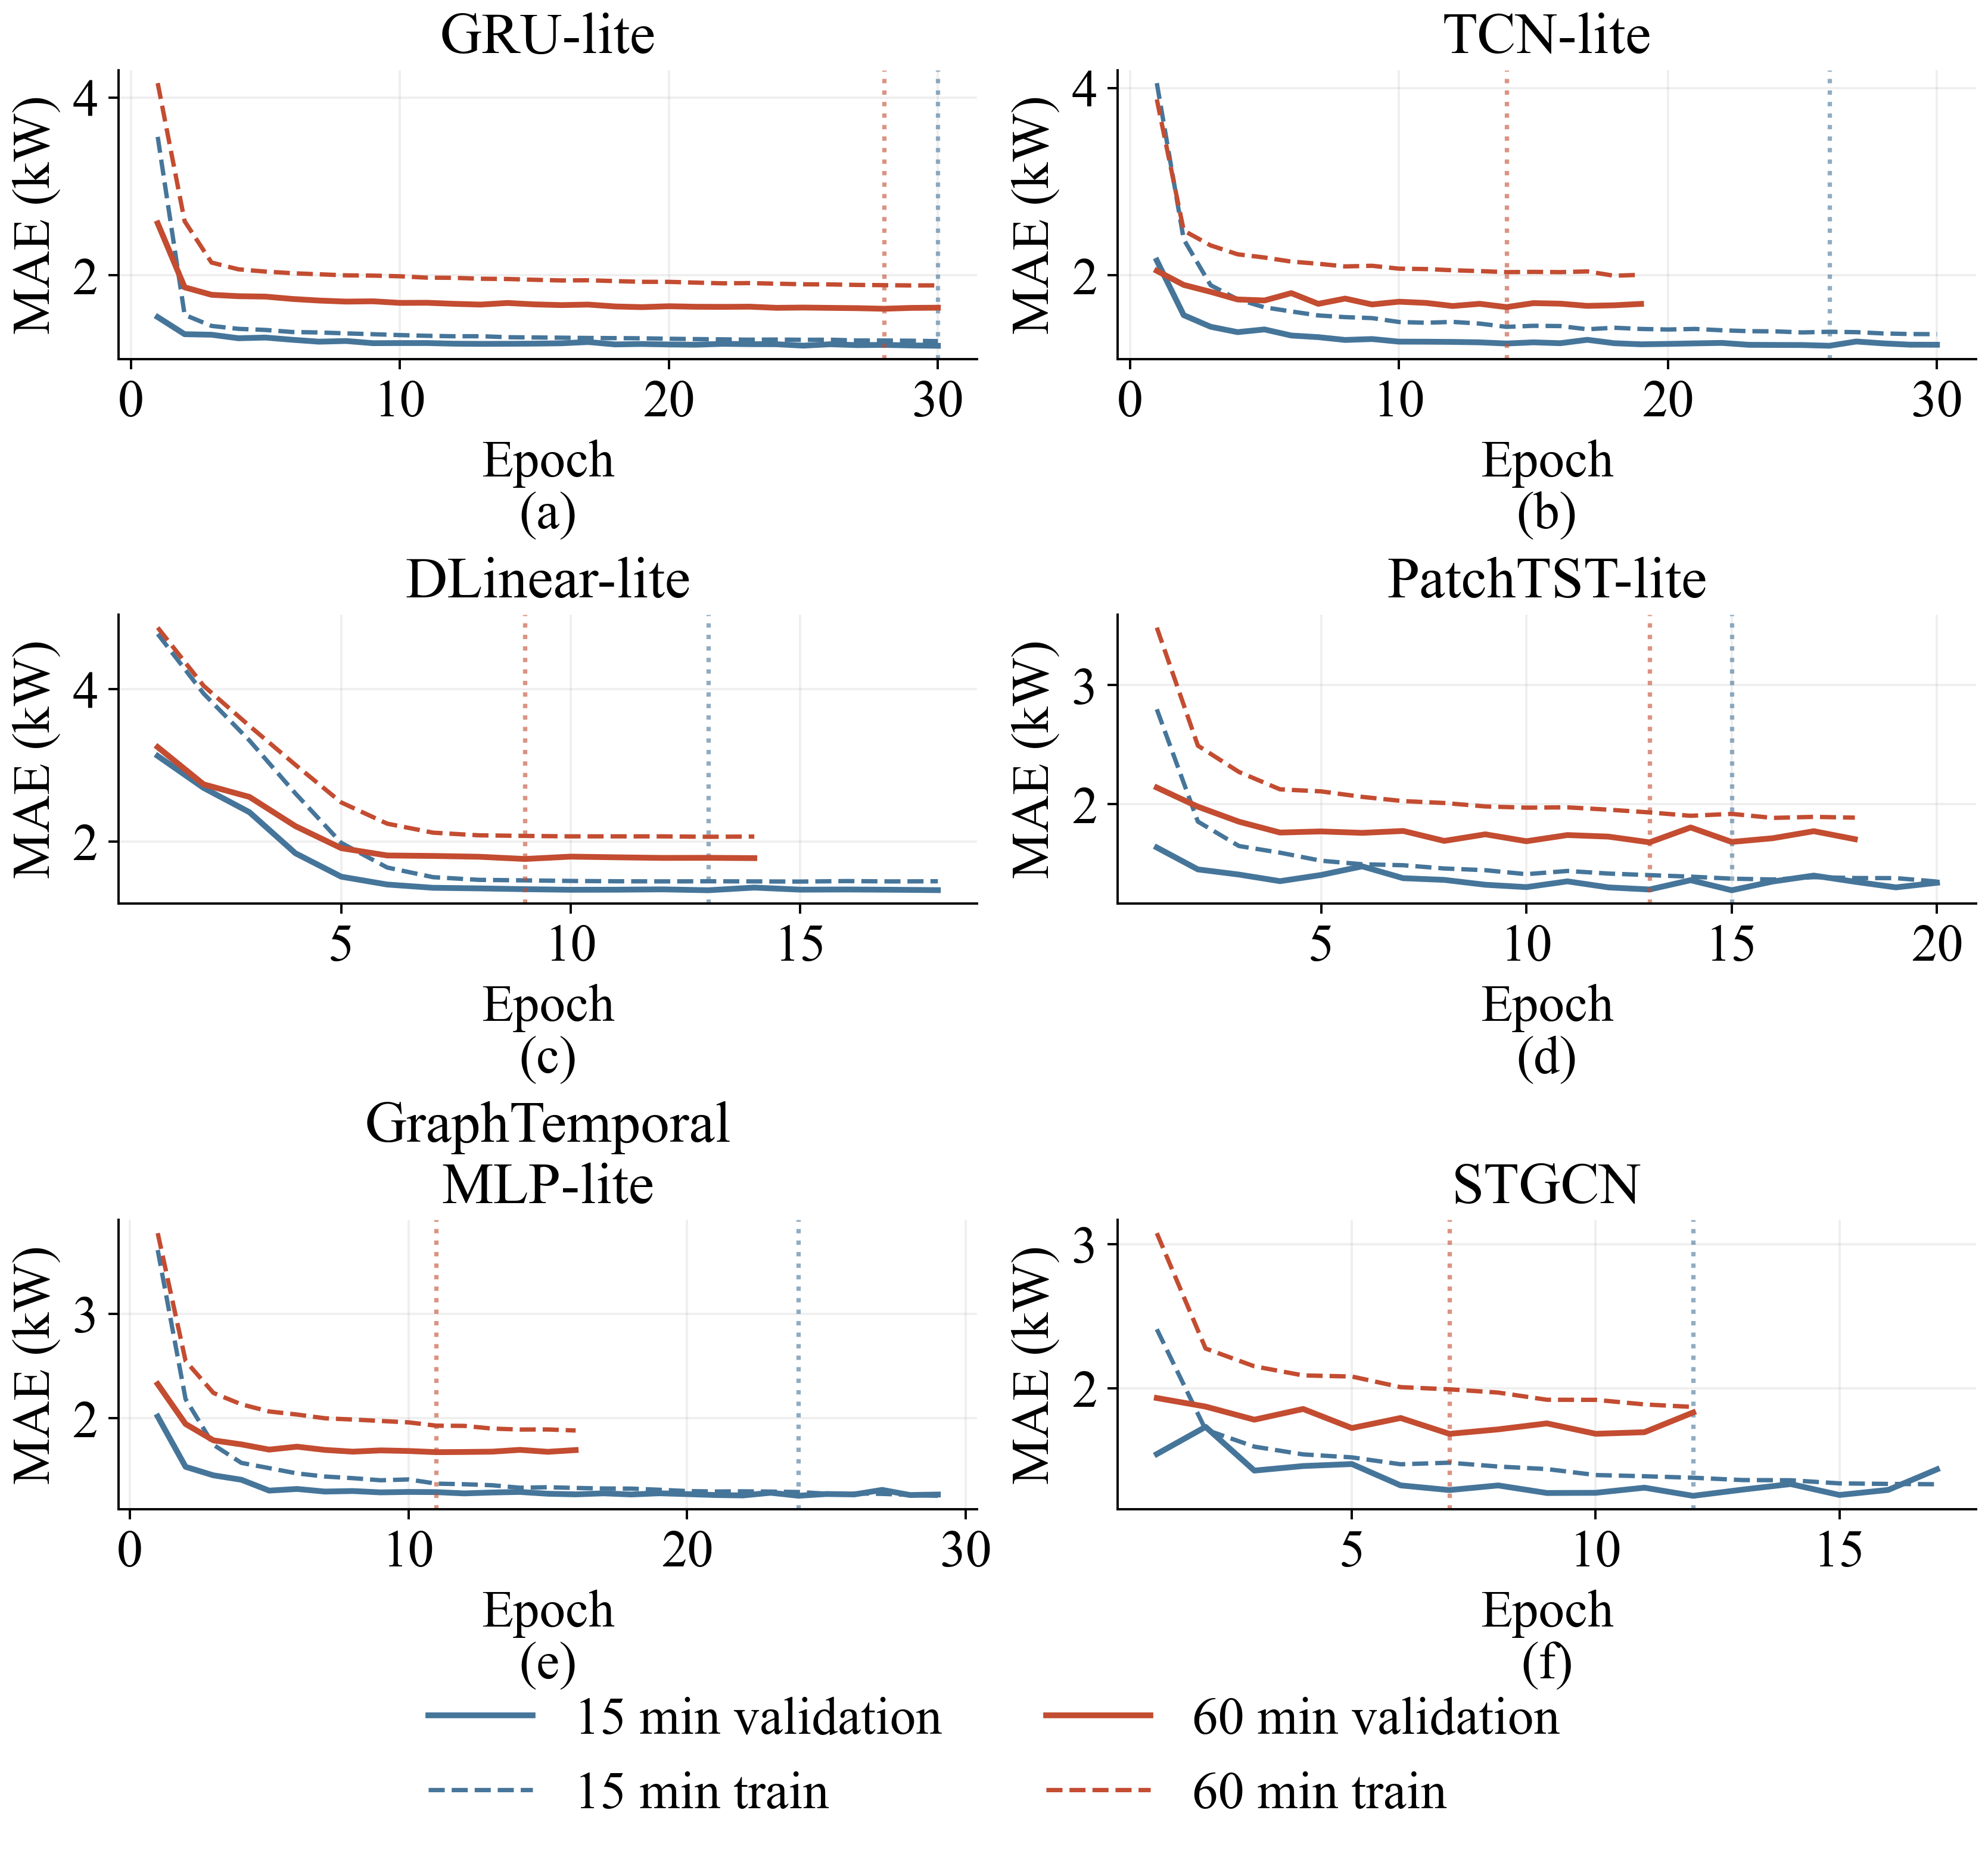

In [14]:
curves=pd.read_csv(TABLE_DIR/'modern_training_curves.csv')
selected=pd.read_csv(TABLE_DIR/'modern_selected_validation_configs.csv')
selected=selected.loc[selected.seed.eq(protocol['seeds'][0])]
fig,axes=plt.subplots(3,2,figsize=(9.5, 9.0),layout='constrained');curve_plot=[]
for ax,model in zip(axes.flat,selected.model.unique()):
    for h,color in [(15,'#46759a'),(60,'#c34c31')]:
        best=selected.loc[selected.model.eq(model)&selected.horizon_minutes.eq(h)].iloc[0]
        data=curves.loc[curves.model.eq(model)&curves.horizon_minutes.eq(h)&curves.seed.eq(best.seed)&curves.phase.eq(best.phase)].sort_values('epoch')
        curve_plot.append(data)
        ax.plot(data.epoch,data.validation_MAE,color=color,label=f'{h} min validation',linewidth=2)
        ax.plot(data.epoch,data.train_MAE,color=color,linestyle='--',label=f'{h} min train',linewidth=1.5)
        ax.axvline(best.best_validation_epoch,color=color,linestyle=':',alpha=.6)
    ax.set(title=model.replace('GraphTemporalMLP-lite','GraphTemporal\nMLP-lite'),xlabel='Epoch',ylabel='MAE (kW)');ax.grid(alpha=.2)
outside_legend(fig,axes.flat[0],2)
panel_letters(axes);save_figure(fig,'revision_selected_learning_curves',pd.concat(curve_plot))


The curves show the selected configurations for the first protocol seed. Dotted lines mark the previously selected validation epochs. The limited tuning budget defines the scope of this comparison.

## Observed versus predicted net load

Source: saved final ExtraTrees and IA-GTPF predictions, seed 11.

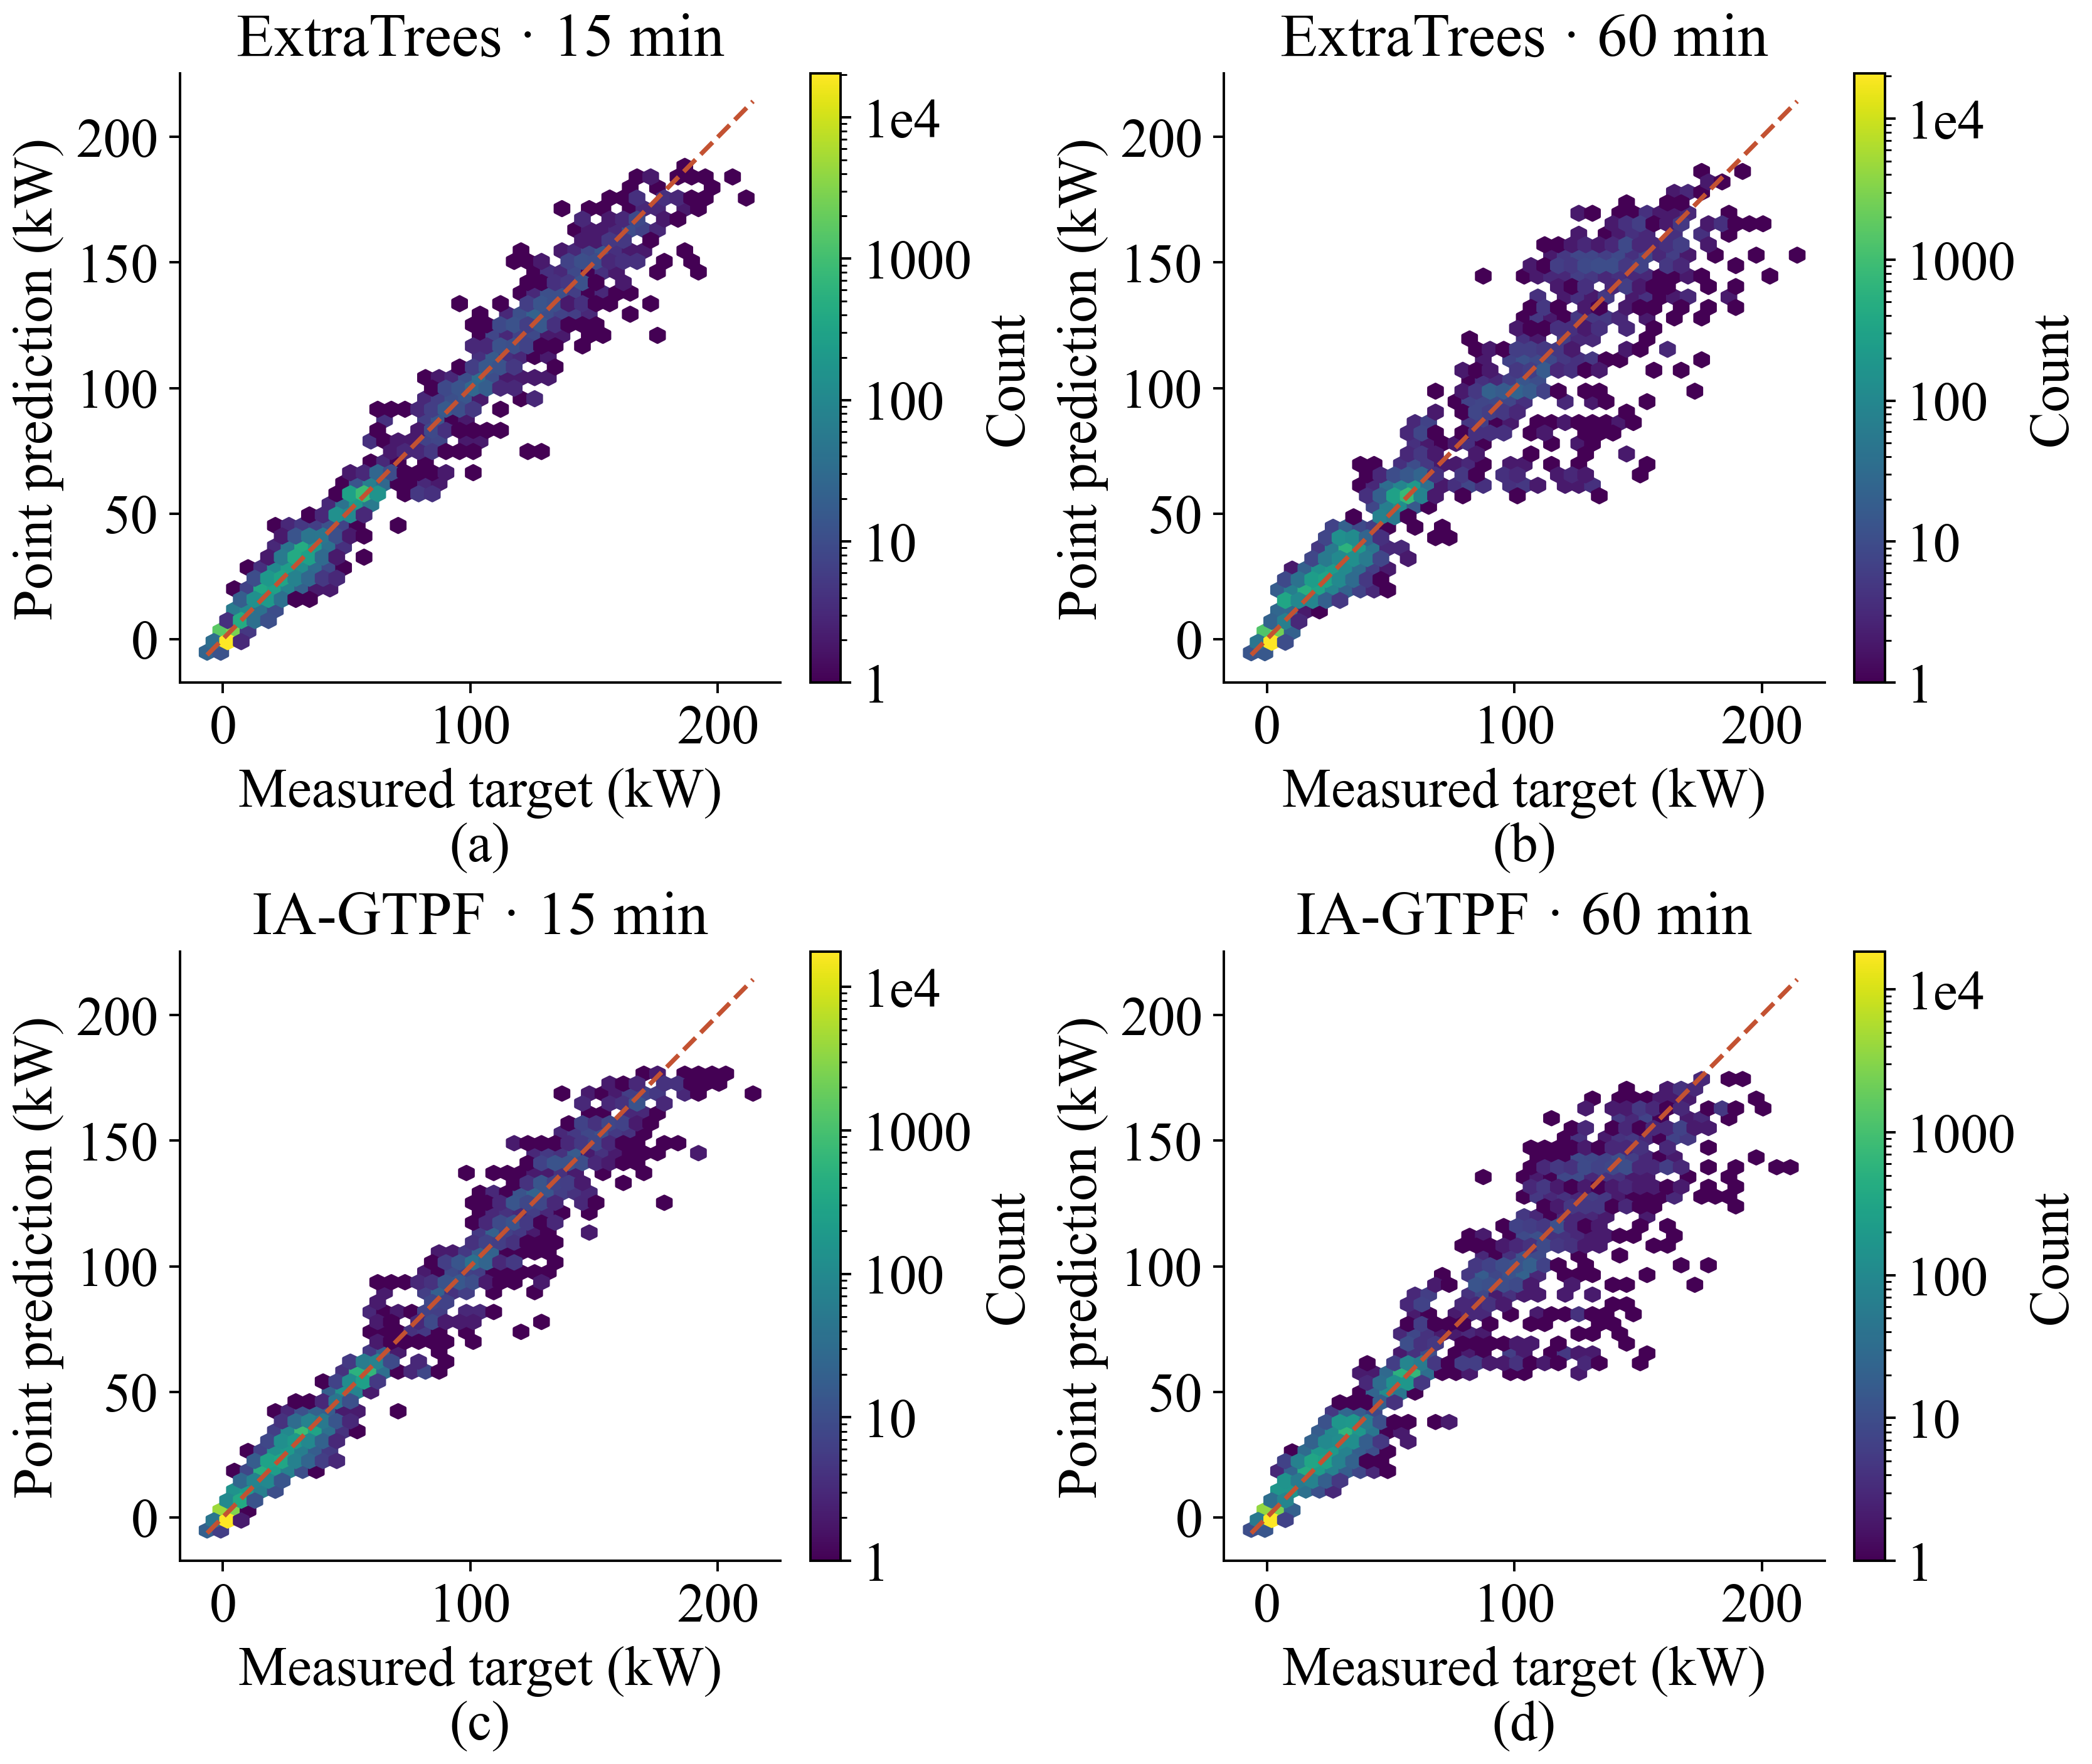

In [12]:
saved_predictions=pd.read_csv(VISUAL_DATA/'revision_prediction_quality.csv',index_col=0)
fig,axes=plt.subplots(2,2,figsize=(9.5, 8.0),layout='constrained');records=[]
for i,model in enumerate(['ExtraTrees','IA-GTPF']):
    for j,h in enumerate([1,4]):
        d=saved_predictions.loc[saved_predictions.model.eq(model)&saved_predictions.horizon_minutes.eq(15*h)].copy();records.append(d[['actual','pred','site','timestamp']].assign(model=model,horizon_minutes=15*h))
        ax=axes[i,j];im=ax.hexbin(d.actual,d.pred,gridsize=40,mincnt=1,bins='log',cmap='viridis');low=min(d.actual.min(),d.pred.min());high=max(d.actual.max(),d.pred.max());ax.plot([low,high],[low,high],'--',color=C['orange']);ax.set(xlabel='Measured target (kW)',ylabel='Point prediction (kW)',title=f'{model} · {h*15} min');fig.colorbar(im,ax=ax).set_label('Count')
panel_letters(axes);save_figure(fig,'revision_prediction_quality',pd.concat(records,ignore_index=True))


All eligible measured test targets are shown for the predeclared first seed. The diagonal is an agreement reference; no observations are selected by prediction error.

## Distribution of absolute forecast errors

Source: saved full-test predictions; deterministic Persistence uses seed 0.

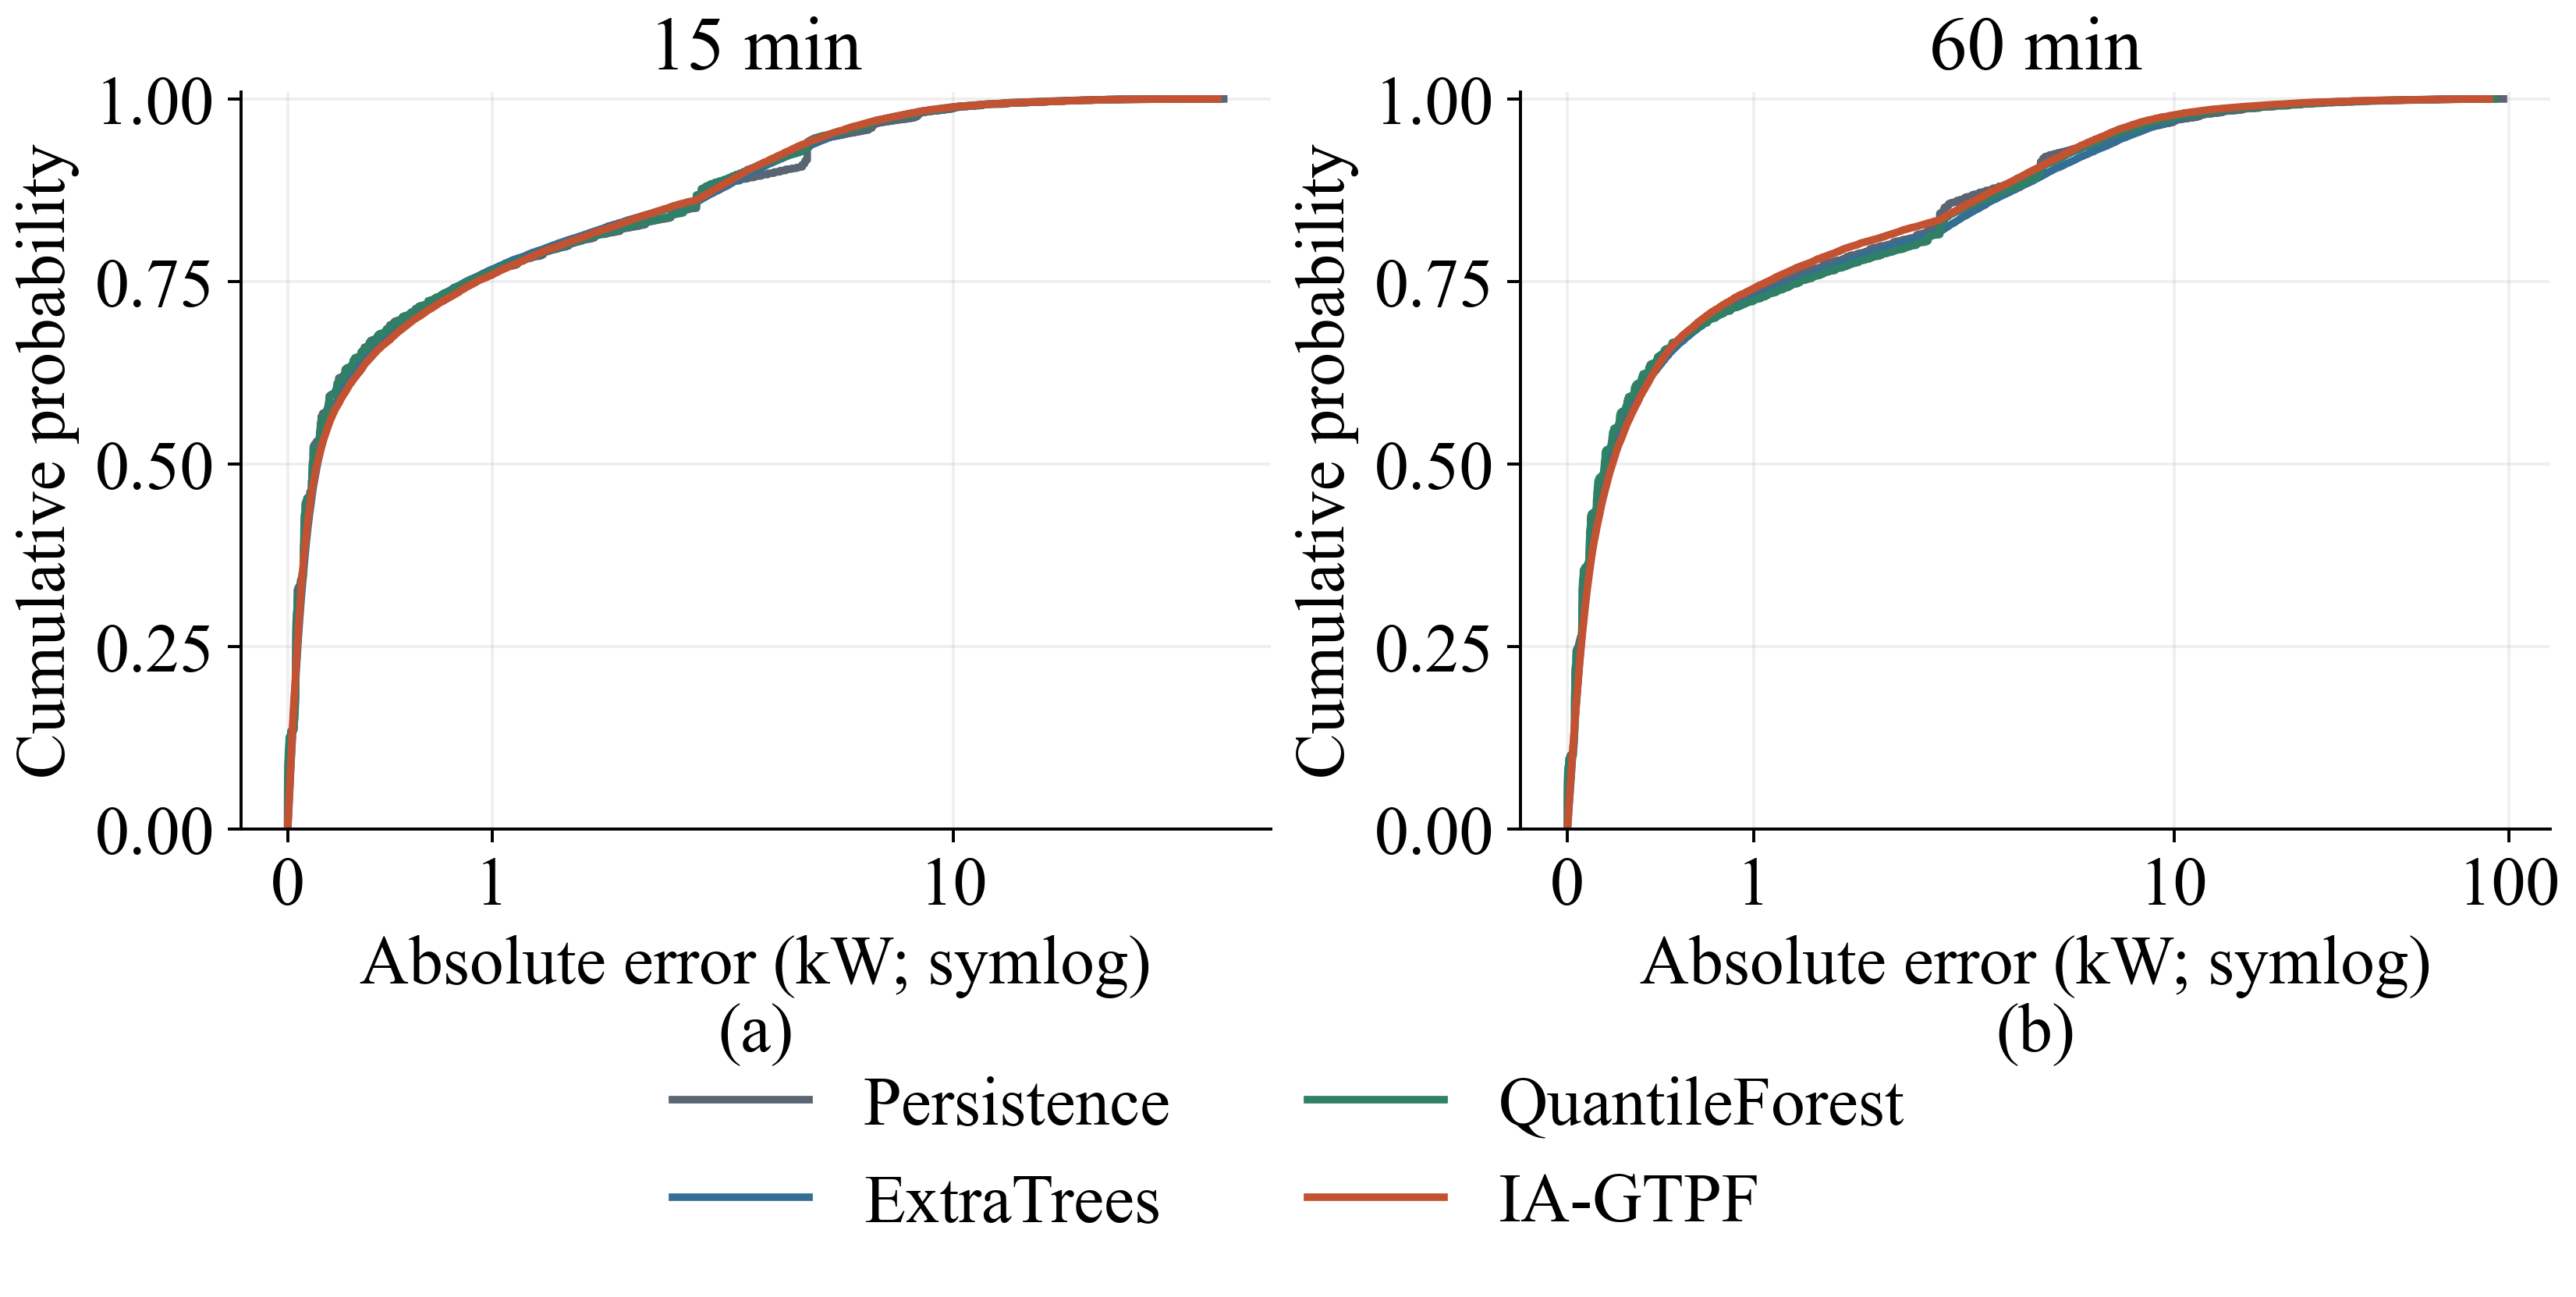

In [13]:
frozen_errors=pd.read_csv(VISUAL_DATA/'revision_absolute_error_distribution.csv',index_col=0)
fig,axes=plt.subplots(1,2,figsize=(9.4, 4.8),layout='constrained');records=[]
for ax,h in zip(axes,[1,4]):
    for model,color in [('Persistence',C['gray']),('ExtraTrees',C['blue']),('QuantileForest',C['green']),('IA-GTPF',C['orange'])]:
        d=frozen_errors.loc[frozen_errors.model.eq(model)&frozen_errors.horizon_minutes.eq(15*h)];error=d.absolute_error_kw.to_numpy();cdf=d.empirical_cdf.to_numpy()
        ax.plot(error,cdf,label=model,color=color,linewidth=2);records.append(pd.DataFrame({'model':model,'horizon_minutes':15*h,'absolute_error_kw':error,'empirical_cdf':cdf}))
    ax.set(xscale='symlog',xlabel='Absolute error (kW; symlog)',ylabel='Cumulative probability',title=f'{15*h} min',ylim=(0,1.01));ax.grid(alpha=.2)
outside_legend(fig,axes[0],2);panel_letters(axes);save_figure(fig,'revision_absolute_error_distribution',pd.concat(records,ignore_index=True))


The full error distribution is retained, including rare large errors. The CDF is descriptive for one predeclared seed; paired uncertainty across seeds and time blocks is reported separately.